# 📊 Histórico de acciones Nasdaq con yfinance

Notebook para descargar datos históricos diarios y visualizar precio y volumen. Prueba Guardado GitDoc 3
 2
**Solo tienes que modificar la CELDA 1** para elegir el valor y el rango de fechas.

In [2]:
# ================================================================
# 📊 CONFIGURACIÓN — MODIFICA AQUÍ
# ================================================================

# ------------------------------------------------
# 1️⃣ VALOR A DESCARGAR
# ------------------------------------------------

# 👉 DEJA ACTIVA UNA SOLA LÍNEA

#TICKER = "META"

# Descomenta UNA de estas si quieres cambiar de empresa:
# TICKER = "AMZN"      # Amazon
TICKER = "NVDA"      # NVIDIA
# TICKER = "MSFT"      # Microsoft
# TICKER = "AAPL"      # Apple
# TICKER = "GOOGL"     # Alphabet
# TICKER = "AVGO"      # Broadcom
# TICKER = "TSLA"      # Tesla
# TICKER = "COST"      # Costco
# TICKER = "NFLX"      # Netflix


# ------------------------------------------------
# 2️⃣ FECHAS DEL HISTÓRICO
# ------------------------------------------------
# 👉 MODIFICA ESTAS DOS FECHAS
# Por defecto: últimos 12 meses

FECHA_INICIO = "2025-08-20"
FECHA_FIN    = "2026-08-20"


# ================================================================
# NO ES NECESARIO MODIFICAR NADA MÁS
# ================================================================

print("=" * 60)
print("📊 CONFIGURACIÓN")
print("=" * 60)
print(f"Valor:        {TICKER}")
print(f"Fecha inicio: {FECHA_INICIO}")
print(f"Fecha fin:    {FECHA_FIN}")
print("=" * 60)


📊 CONFIGURACIÓN
Valor:        NVDA
Fecha inicio: 2025-08-20
Fecha fin:    2026-08-20


In [3]:
# ================================================================
# 📦 LIBRERÍAS
# ================================================================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [4]:
# ================================================================
# 📥 DESCARGAR DATOS HISTÓRICOS
# ================================================================

print()
print(f"📥 Descargando {TICKER}...")
print(f"📅 Desde {FECHA_INICIO} hasta {FECHA_FIN}")

df = yf.download(
    TICKER,
    start=FECHA_INICIO,
    end=FECHA_FIN,
    interval="1d",
    auto_adjust=False,
    progress=False
)

if df.empty:
    print("❌ No se han descargado datos.")
else:
    print("✅ Descarga completada")
    print()
    print(f"Velas descargadas: {len(df)}")
    print(f"Primera fecha:     {df.index.min()}")
    print(f"Última fecha:      {df.index.max()}")



📥 Descargando NVDA...
📅 Desde 2025-08-20 hasta 2026-08-20
✅ Descarga completada

Velas descargadas: 251
Primera fecha:     2025-08-20 00:00:00
Última fecha:      2026-08-19 00:00:00


In [5]:
# ================================================================
# 🧹 PREPARAR DATOS
# ================================================================

df = df.reset_index()

# yfinance puede devolver columnas multinivel.
# Las simplificamos para trabajar cómodamente.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        col[0] if col[1] == "" else col[0]
        for col in df.columns
    ]

columnas = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

df = df[[col for col in columnas if col in df.columns]]

print("✅ Datos preparados")
print()

display(df.head())


✅ Datos preparados



,Date,Open,High,Low,Close,Volume
0,2025-08-20,175.169998,176.000000,168.800003,175.399994,215142700
1,2025-08-21,174.850006,176.899994,173.809998,174.979996,140040900
2,2025-08-22,172.610001,178.589996,171.199997,177.990005,172789400
3,2025-08-25,178.350006,181.910004,176.570007,179.809998,163012800
4,2025-08-26,180.059998,182.389999,178.809998,181.770004,168688200


In [6]:
# ================================================================
# 📋 INFORMACIÓN DEL HISTÓRICO
# ================================================================

print("=" * 60)
print(f"📈 {TICKER}")
print("=" * 60)

print(f"Sesiones:       {len(df):,}")
print(f"Desde:          {df["Date"].min().date()}")
print(f"Hasta:          {df["Date"].max().date()}")

print()
print("Columnas disponibles:")
print(list(df.columns))

print()
print("Últimas 10 sesiones:")

display(df.tail(10))


📈 NVDA
Sesiones:       251
Desde:          2025-08-20
Hasta:          2026-08-19

Columnas disponibles:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Últimas 10 sesiones:


,Date,Open,High,Low,Close,Volume
241,2026-08-06,221.529999,223.630005,217.000000,218.990005,113940600
242,2026-08-07,221.539993,224.759995,220.660004,223.960007,105669400
243,2026-08-10,223.399994,224.139999,216.770004,217.550003,115846600
244,2026-08-11,222.169998,222.199997,216.199997,217.500000,101273100
245,2026-08-12,221.039993,225.100006,220.199997,224.089996,108783600
246,2026-08-13,225.059998,227.229996,223.710007,225.300003,98867200
247,2026-08-14,226.770004,227.490005,224.500000,225.160004,75680900
248,2026-08-17,225.979996,227.919998,224.860001,225.009995,93678700
249,2026-08-18,220.449997,221.639999,218.690002,219.740005,103128200
250,2026-08-19,221.669998,222.869995,216.759995,217.559998,96854269


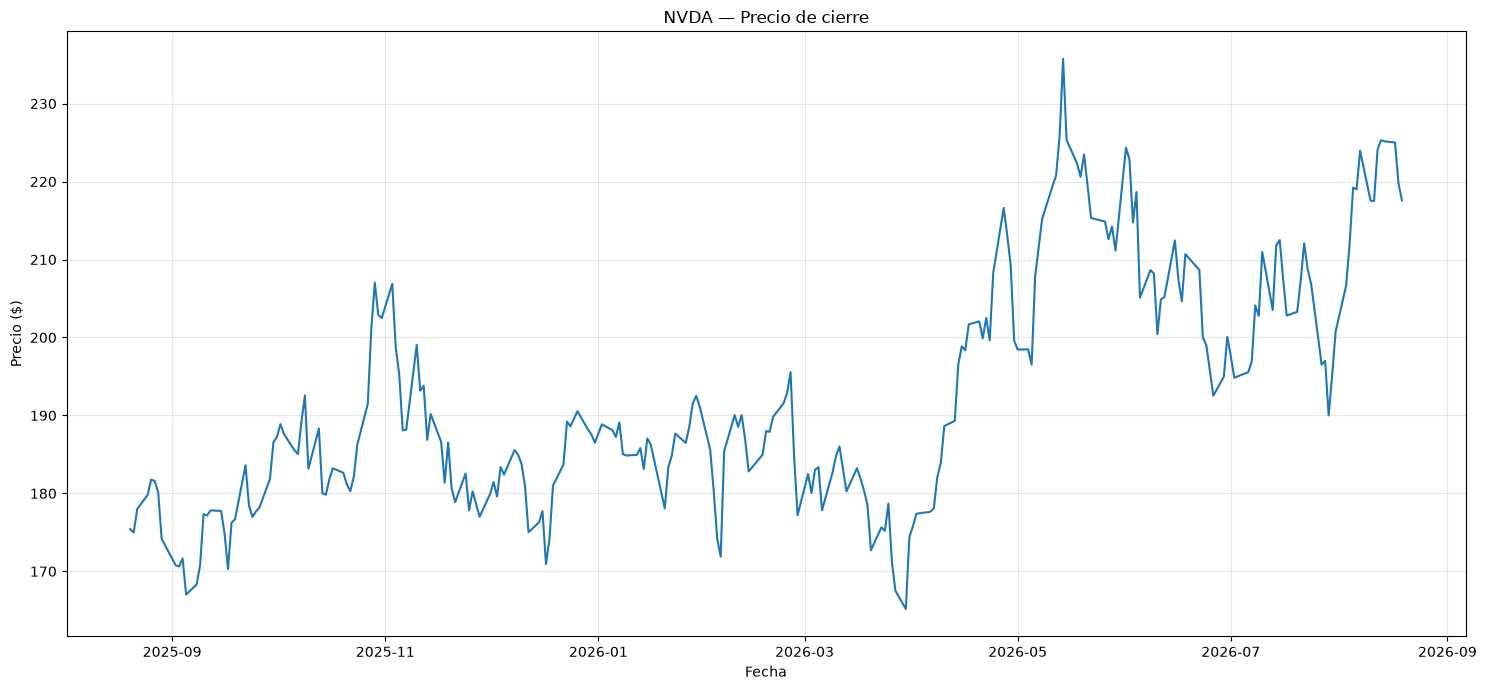

In [7]:
# ================================================================
# 📈 GRÁFICA DEL PRECIO
# ================================================================

plt.figure(figsize=(15, 7))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=1.5
)

plt.title(f"{TICKER} — Precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


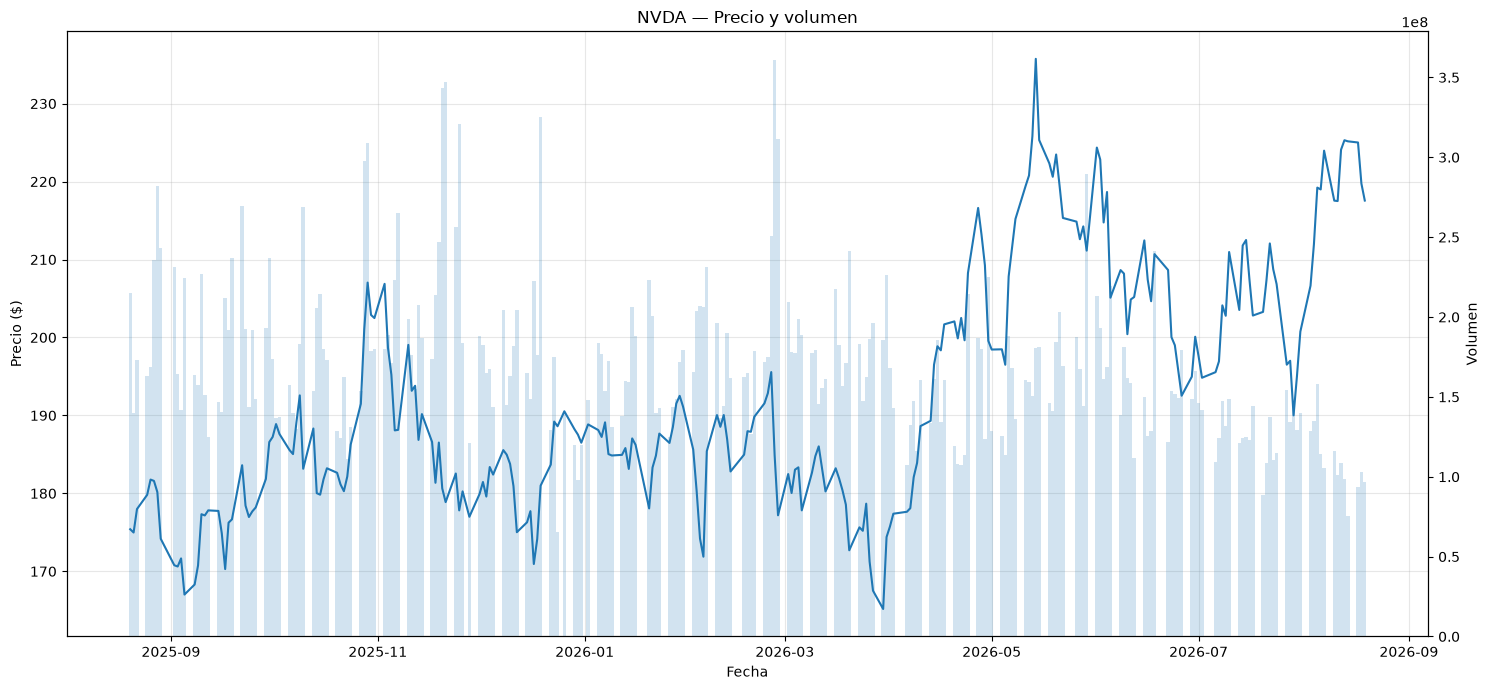

In [8]:
# ================================================================
# 📊 PRECIO + VOLUMEN
# ================================================================

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(
    df["Date"],
    df["Close"],
    linewidth=1.5,
    label="Precio"
)

ax1.set_xlabel("Fecha")
ax1.set_ylabel("Precio ($)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.bar(
    df["Date"],
    df["Volume"],
    alpha=0.2,
    width=1
)

ax2.set_ylabel("Volumen")

plt.title(f"{TICKER} — Precio y volumen")
plt.tight_layout()
plt.show()


In [9]:
# ================================================================
# 💾 GUARDAR CSV
# ================================================================

NOMBRE_ARCHIVO = f"{TICKER}_{FECHA_INICIO}_{FECHA_FIN}.csv"

df.to_csv(
    NOMBRE_ARCHIVO,
    index=False
)

print("✅ CSV guardado")
print()
print(f"📁 {NOMBRE_ARCHIVO}")


✅ CSV guardado

📁 NVDA_2025-08-20_2026-08-20.csv
